[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/badaouihakimou/machine-learning-notebooks/blob/main/24_apprentisage_non_supervise.ipynb)



# L'apprentissage non supervisé

Jusqu'ici, chaque exemple avait une étiquette `y` l'espèce de la fleur, la
survie du passager. On apprenait à prédire cette réponse connue. C'est
l'apprentissage supervisé.

L'apprentissage non supervisé est différent : il n'y a pas de `y`. On donne
au modèle des données brutes et on lui demande d'y trouver une structure tout seul.
Regrouper ce qui se ressemble, repérer ce qui détonne, simplifier ce qui est
complexe.

## Le plan

| Section | Le sujet | L'algorithme |
|---|---|---|
| 1 | Le clustering | K-Means |
| 2 | Choisir le nombre de groupes | méthode du coude |
| 3 | La détection d'anomalies | Isolation Forest |
| 4 | La réduction de dimension | PCA |
| 5 | PCA : compresser une image | reconstruction |

## Trois pièges annoncés

`k_means` (fonction) et `KMeans` (classe) sont deux objets différents n utilise
la classe.

Sans `random_state`, K-Means peut converger vers des groupes différents à chaque
exécution.

Et il faut toujours standardiser avant un PCA, sinon une variable à grande
échelle domine tout.

Prérequis : les notebooks 20 à 23.

## 1. Le clustering avec K-Means

Le clustering regroupe les données en paquets les *clusters* de sorte que
les points d'un même groupe se ressemblent. Sans étiquette : l'algorithme trouve
les groupes seul.

### Générer des données de test

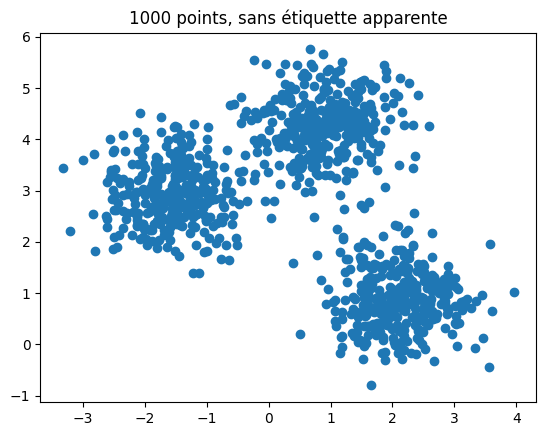

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=1000, centers=3, cluster_std=0.6, random_state=0)

plt.scatter(X[:, 0], X[:, 1])
plt.title('1000 points, sans étiquette apparente')
plt.show()

`make_blobs` fabrique des paquets de points ici 3 groupes de 1000 points au
total. On voit trois nuages à l'œil, mais l'algorithme, lui, ne reçoit que les
positions `X`, jamais les groupes `y`.

Un piège dans le code d'origine : `plt.scatter(X[:,0], X[:,0])` traçait la
première colonne contre elle-même d'où une ligne diagonale. Il faut
`X[:,0]` contre `X[:,1]`, les deux colonnes différentes.

### Appliquer K-Means

In [37]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=3, n_init=10, random_state=0)
model.fit(X)

print('clusters trouvés :', np.unique(model.labels_))

clusters trouvés : [0 1 2]


Le piège K-Means / k_means. sklearn a deux objets de noms proches :

`k_means` (minuscule) est une fonction qui renvoie des tableaux bruts.

`KMeans` (majuscule) est la classe, un modèle avec `.fit`, `.predict`, comme
tous les autres. C'est celle qu'on utilise, cohérente avec le reste du cours.

Le code d'origine mélangeait les deux et appelait `model.fit()` sans argument.

Les paramètres importants :

`n_clusters` : le nombre de groupes à former ici 3.

`n_init=10` : K-Means démarre depuis des positions aléatoires, et le résultat en
dépend. `n_init=10` relance 10 fois et garde le meilleur important pour la
stabilité.

`random_state` : fixe le hasard, pour un résultat reproductible.

### Voir les groupes trouvés

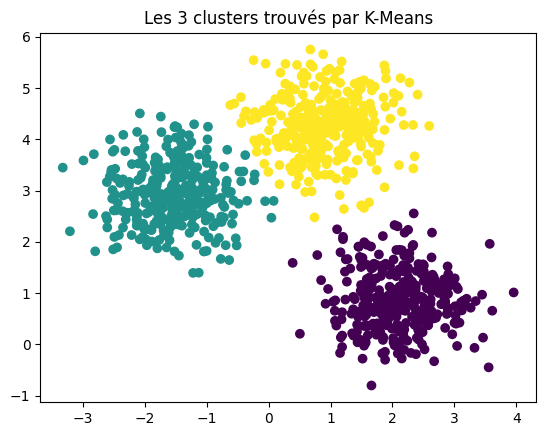

In [38]:
plt.scatter(X[:, 0], X[:, 1], c=model.labels_)
plt.title('Les 3 clusters trouvés par K-Means')
plt.show()

`labels_` donne le groupe attribué à chaque point. En colorant par ce label, on
voit les trois clusters retrouvés sans que l'algorithme ait vu les vraies
étiquettes.

### Les centres des clusters

K-Means place un centre au milieu de chaque groupe. C'est le cœur de son
fonctionnement : chaque point est rattaché au centre le plus proche.

centres :
[[ 2.09874471  0.8797929 ]
 [-1.55076244  2.93708061]
 [ 0.90656438  4.27562312]]


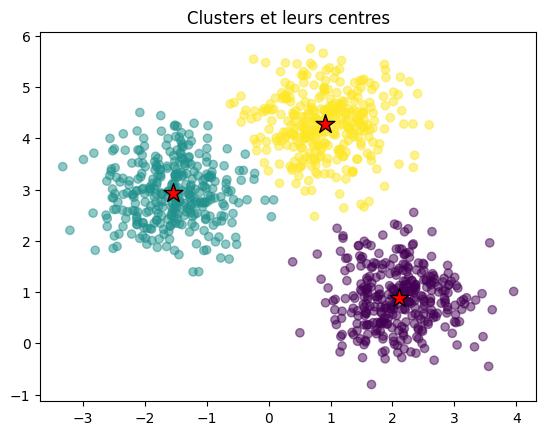

In [39]:
print('centres :')
print(model.cluster_centers_)

plt.scatter(X[:, 0], X[:, 1], c=model.labels_, alpha=0.5)
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1],
            c='red', s=200, marker='*', edgecolor='black')
plt.title('Clusters et leurs centres')
plt.show()

Les étoiles rouges sont les centres. K-Means fonctionne en déplaçant ces centres
jusqu'à ce qu'ils se stabilisent au cœur de chaque groupe.

### Prédire pour de nouveaux points

Une fois entraîné, `predict` assigne un cluster à un nouveau point celui du
centre le plus proche.

In [40]:
nouveaux = np.array([[0, 0], [-5, 5], [3, 2]])
print('clusters prédits :', model.predict(nouveaux))

clusters prédits : [0 1 0]


## 2. Choisir le nombre de clusters : la méthode du coude

Le problème : `n_clusters=3` était un choix. Comment savoir combien de groupes
existent vraiment, quand on ne les voit pas ?

### L'inertie, mesure de qualité

K-Means fournit l'inertie : la somme des distances de chaque point à son
centre. Plus elle est basse, plus les groupes sont compacts.

In [41]:
print('inertie :', round(model.inertia_, 1))
print('score  :', round(model.score(X), 1))

inertie : 681.1
score  : -681.1


Le point de ton commentaire, confirmé : `inertia_` et `score` sont la même
valeur, au signe près. L'inertie est positive (un coût à minimiser), le score
est son opposé négatif car sklearn maximise toujours le score, comme pour le
`neg_mean_squared_error` du notebook 21.2. Deux façons d'exprimer la même chose.

### La méthode du coude (Elbow)

L'idée : calculer l'inertie pour plusieurs valeurs de `k`, et repérer le coude
de la courbe le point où ajouter un cluster cesse d'aider beaucoup.

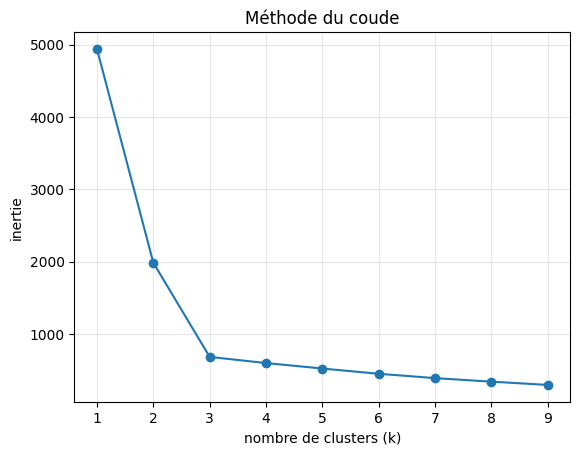

In [42]:
inerties = []
k_range = range(1, 10)

for k in k_range:
    model = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    inerties.append(model.inertia_)

plt.plot(k_range, inerties, marker='o')
plt.xlabel('nombre de clusters (k)')
plt.ylabel('inertie')
plt.title('Méthode du coude')
plt.grid(alpha=0.3)
plt.show()

Attention aux erreurs du code d'origine : `plt.plot(k_range, Inertia):` avait
un deux-points parasite à la fin, et les deux `plt.xlabel` écrasaient l'un l'autre
(le second aurait dû être `ylabel`).

### Lire le coude

La courbe chute fortement, puis s'aplatit. Le coude le point de cassure
indique le bon nombre de clusters.

In [43]:
chutes = np.diff(inerties)
print('inertie par k :', [round(i) for i in inerties])
print('chute à chaque ajout :', [round(c) for c in chutes])

inertie par k : [4939, 1984, 681, 596, 520, 448, 388, 339, 294]
chute à chaque ajout : [-2955, -1302, -85, -76, -73, -60, -49, -45]


Les chiffres parlent. L'inertie s'effondre de k=1 à k=3 (chutes de -2955 puis
-1302), puis les chutes deviennent petites (-85, -76...). Le coude est à k=3.

C'est logique : les données ont vraiment 3 groupes. Au-delà, découper davantage
ne fait que fragmenter des groupes déjà bons, d'où le faible gain.

L'interprétation. Avant le coude, chaque cluster ajouté capture une vraie
structure l'inertie chute fort. Après, on découpe artificiellement le gain
devient marginal. Le coude est le meilleur compromis entre simplicité (peu de
groupes) et compacité (inertie basse).

C'est la même logique que la courbe de validation du notebook 21 : un optimum
entre trop simple et trop complexe, lu sur une courbe.

### Autres algorithmes de clustering

K-Means n'est pas le seul. Selon la forme des données, d'autres conviennent mieux :

DBSCAN regroupe par densité, trouve des clusters de forme quelconque et
repère le bruit. Idéal quand les groupes ne sont pas des boules rondes.

AgglomerativeClustering construit une hiérarchie de groupes, fusionnés
progressivement. Donne un arbre (dendrogramme).

SpectralClustering utilise les graphes, efficace sur des structures
complexes et entrelacées.

K-Means reste le point de départ : simple, rapide, efficace quand les groupes sont
à peu près sphériques et de taille comparable.

## 3. La détection d'anomalies : Isolation Forest

Autre tâche non supervisée : repérer les points anormaux ceux qui ne
ressemblent à aucun autre. Fraude, panne, défaut de fabrication.

`IsolationForest` isole ces points : une anomalie, étant à part, est facile à
séparer du reste.

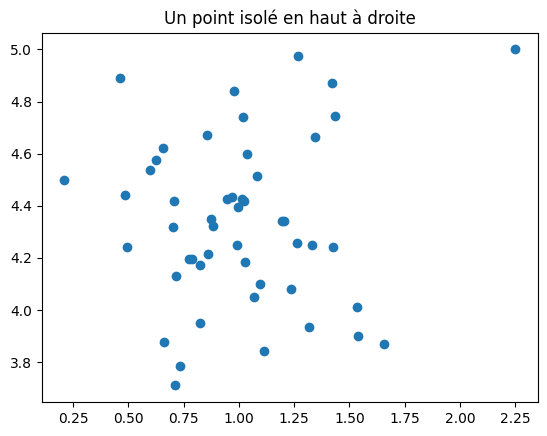

In [44]:
from sklearn.datasets import make_blobs

# Un groupe compact, plus un point isolé
X, y = make_blobs(n_samples=50, centers=1, cluster_std=0.3, random_state=0)
X[-1, :] = np.array([2.25, 5]) # une anomalie manuelle

plt.scatter(X[:, 0], X[:, 1])
plt.title('Un point isolé en haut à droite')
plt.show()

In [45]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.05, random_state=0)
model.fit(X)

predictions = model.predict(X)
print('valeurs possibles :', np.unique(predictions))

valeurs possibles : [-1  1]


`IsolationForest` renvoie 1 pour un point normal, -1 pour une anomalie.

`contamination` est la proportion attendue d'anomalies ici 5 %. C'est un réglage
important : trop haut, on signale des points normaux ; trop bas, on rate de vraies
anomalies.

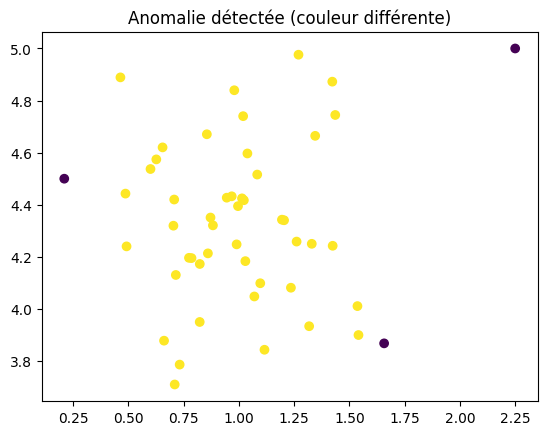

In [46]:
plt.scatter(X[:, 0], X[:, 1], c=model.predict(X))
plt.title('Anomalie détectée (couleur différente)')
plt.show()

Le point isolé est détecté et coloré différemment. L'algorithme l'a trouvé sans
étiquette juste en remarquant qu'il est facile à isoler du reste.

### Application : trouver les chiffres bizarres

Prenons le jeu `digits` des images 8×8 de chiffres manuscrits et cherchons
ceux qui sont mal écrits.

X : (1797, 64) -> 1797 images de 64 pixels (8x8)


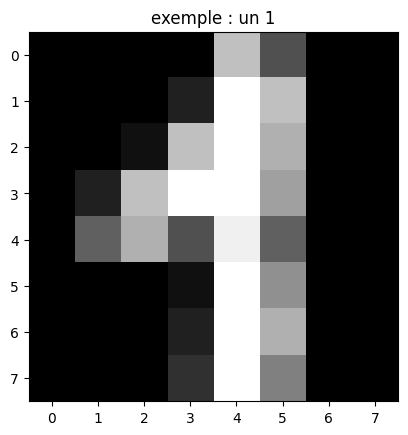

In [47]:
from sklearn.datasets import load_digits

digits = load_digits()
images = digits.images
X = digits.data
y = digits.target

print('X :', X.shape, '-> 1797 images de 64 pixels (8x8)')

plt.imshow(images[42], cmap='gray')
plt.title(f'exemple : un {y[42]}')
plt.show()

In [48]:
model = IsolationForest(random_state=0, contamination=0.02)
model.fit(X)

outliers = model.predict(X) == -1
print('anomalies détectées :', outliers.sum(), 'sur', len(X))

anomalies détectées : 36 sur 1797


`outliers` est un masque booléen : `True` pour les images jugées anormales. Avec
2 % de contamination, on repère les chiffres les plus mal formés.

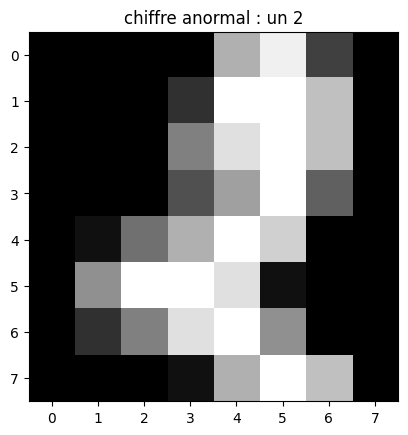

In [49]:
plt.imshow(images[outliers][0], cmap='gray')
plt.title(f'chiffre anormal : un {y[outliers][0]}')
plt.show()

On affiche la première image anormale. Souvent, c'est un chiffre mal tracé,
ambigu, ou atypique exactement ce qu'une détection d'anomalies doit trouver.

L'intérêt concret. Sur de vraies données, cette technique repère les erreurs
de saisie, les fraudes, les défauts tout ce qui s'écarte de la norme, sans
qu'on ait eu besoin d'étiqueter au préalable ce qui est « anormal ».

### Autres algorithmes de détection

LocalOutlierFactor compare la densité locale d'un point à celle de ses
voisins. Un point dans une zone bien moins dense que son entourage est une
anomalie.

Novelty detection variante qui apprend sur des données propres, puis détecte
les anomalies dans de nouvelles données (le test). Utile pour surveiller un
système en production.

## 4. La réduction de dimension : PCA

Troisième grande tâche non supervisée. Le jeu `digits` a 64 dimensions (les 64
pixels). C'est beaucoup lent à traiter, difficile à visualiser, et sujet au
« fléau de la dimension » : en haute dimension, tout devient loin de tout.

Le PCA (*Principal Component Analysis*) réduit le nombre de dimensions en
gardant l'essentiel de l'information.

In [50]:
from sklearn.decomposition import PCA

X = digits.data  # 64 dimensions
print('avant PCA :', X.shape)

model = PCA(n_components=2)
X_reduced = model.fit_transform(X)

print('après PCA :', X_reduced.shape, '-> réduit à 2 dimensions')

avant PCA : (1797, 64)
après PCA : (1797, 2) -> réduit à 2 dimensions


`PCA(n_components=2)` comprime les 64 dimensions en 2. On passe de 64 nombres
par image à seulement 2, tout en conservant le maximum de structure.

### Visualiser en 2D

L'intérêt immédiat : on peut maintenant tracer les données, impossible en 64
dimensions.

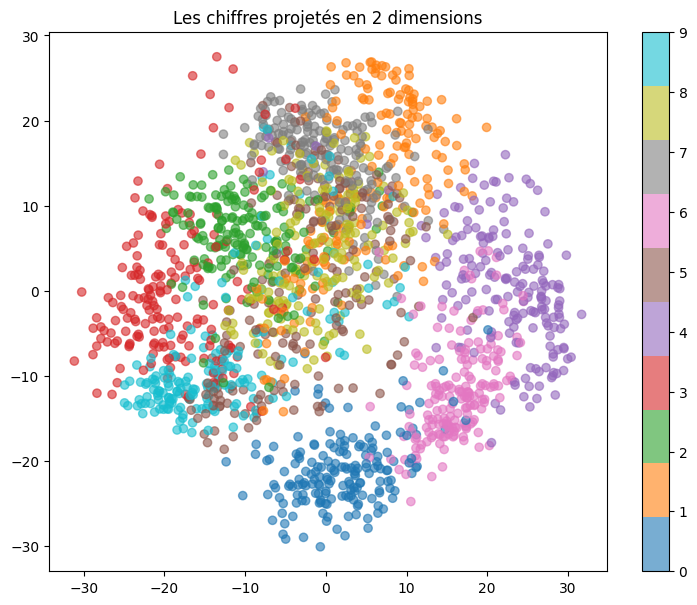

In [51]:
X_reduced = PCA(n_components=2).fit_transform(X)

plt.figure(figsize=(9, 7))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, cmap='tab10', alpha=0.6)
plt.colorbar()
plt.title('Les chiffres projetés en 2 dimensions')
plt.show()

Chaque point est une image, coloré par son chiffre réel. Malgré la compression de
64 à 2 dimensions, les chiffres identiques se regroupent le PCA a préservé la
structure essentielle.

C'est remarquable : on visualise en 2D une information qui vivait en 64D, et les
groupes restent lisibles. Note qu'on utilise `y` seulement pour colorer le
PCA lui-même ne l'a jamais vu, c'est bien du non-supervisé.

### Les composantes principales

In [52]:
model = PCA(n_components=2)
model.fit(X)

print('composantes :', model.components_.shape, '-> 2 directions dans l\'espace 64D')

composantes : (2, 64) -> 2 directions dans l'espace 64D


Le PCA trouve les directions qui capturent le plus de variation dans les
données les composantes principales. Chaque composante est une combinaison des
64 pixels d'origine. Réduire, c'est projeter les données sur ces quelques
directions les plus informatives.

### Combien de composantes garder ?

Comment choisir le nombre de dimensions ? On regarde la variance expliquée :
la part d'information conservée.

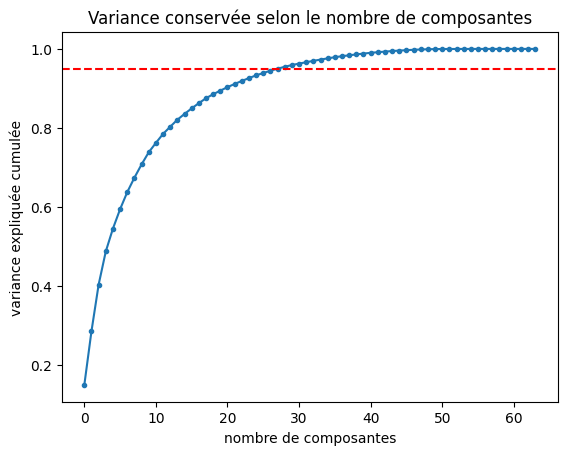

In [53]:
model = PCA(n_components=64).fit(X) # toutes les composantes

variance_cumulee = np.cumsum(model.explained_variance_ratio_)

plt.plot(variance_cumulee, marker='.')
plt.axhline(0.95, color='red', linestyle='--', label='95 %')
plt.xlabel('nombre de composantes')
plt.ylabel('variance expliquée cumulée')
plt.title('Variance conservée selon le nombre de composantes')
plt.show()

`explained_variance_ratio_` donne la part de variance de chaque composante.
`np.cumsum` (le cumul du notebook 12) les additionne. La courbe monte vite : les
premières composantes portent le plus d'information.

### Trouver le nombre idéal automatiquement

In [54]:
n_ideal = np.argmax(variance_cumulee > 0.95) + 1
print('composantes pour garder 95 % :', n_ideal, 'sur 64')

composantes pour garder 95 % : 29 sur 64


`argmax` sur une condition booléenne donne le premier `True` l'idiome du notebook
12. Ici, 29 composantes suffisent pour conserver 95 % de l'information, contre
64 au départ. On divise par plus de deux le nombre de dimensions en ne perdant que
5 % de variance.

Encore plus simple : on peut passer directement la variance voulue à PCA.

In [55]:
model = PCA(n_components=0.95) # garde 95 % de variance
model.fit(X)

print('composantes choisies automatiquement :', model.n_components_)

composantes choisies automatiquement : 29


`PCA(n_components=0.95)` calcule tout seul combien de composantes garder pour 95 %
de variance. Plus besoin de chercher à la main c'est la façon la plus pratique.

## 5. PCA : compresser et reconstruire une image

Le PCA est réversible : `inverse_transform` reconstruit les données depuis leur
version réduite. C'est le meilleur moyen de voir ce que la compression garde
ou perd.

In [56]:
# Réduire à 2 dimensions, puis reconstruire
model = PCA(n_components=2)
X_reduced = model.fit_transform(X)
X_recovered = model.inverse_transform(X_reduced)

print('original :', X.shape)
print('réduit :', X_reduced.shape)
print('reconstruit :', X_recovered.shape)

original : (1797, 64)
réduit : (1797, 2)
reconstruit : (1797, 64)


Le piège du code d'origine : il faisait `inverse_transform(x_reduced)` avec un
`x_reduced` calculé par un autre PCA. Il faut reconstruire depuis le résultat
du même modèle. On garde donc `X_reduced = model.fit_transform(X)` et
`model.inverse_transform(X_reduced)` cohérents.

### Voir l'effet du nombre de composantes

Reconstruisons la même image avec de plus en plus de composantes.

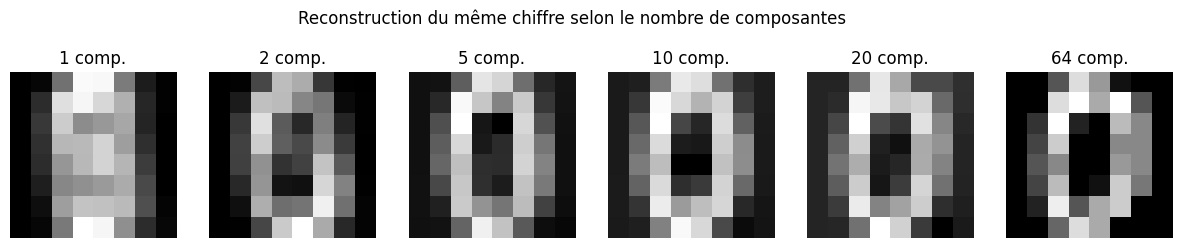

In [57]:
fig, axes = plt.subplots(1, 6, figsize=(15, 3))

for ax, n in zip(axes, [1, 2, 5, 10, 20, 64]):
    model = PCA(n_components=n)
    X_reduced = model.fit_transform(X)
    X_recovered = model.inverse_transform(X_reduced)
    ax.imshow(X_recovered[0].reshape(8, 8), cmap='gray')
    ax.set_title(f'{n} comp.')
    ax.axis('off')

plt.suptitle('Reconstruction du même chiffre selon le nombre de composantes')
plt.show()

La progression est parlante. Avec 1 composante, l'image est floue, méconnaissable.
À mesure qu'on ajoute des composantes, le chiffre se précise. Vers 20, il est déjà
très net ; à 64, c'est l'original exact.

C'est le compromis du PCA rendu visible : peu de composantes = forte compression
mais perte de détail ; beaucoup = fidélité mais peu de gain. Le bon choix est
celui qui garde le chiffre reconnaissable avec le moins de composantes possible.

### Les règles d'or du PCA

Toujours standardiser avant. Le PCA cherche les directions de plus grande
variance. Si une variable a une échelle bien plus grande que les autres, elle
dominera artificiellement comme le KNN du notebook 22. Un `StandardScaler` avant
le PCA est presque toujours nécessaire.

```python
from sklearn.pipeline import make_pipeline
model = make_pipeline(StandardScaler(), PCA(n_components=0.95))
```

Conçu pour des variables continues. Le PCA suppose des relations linéaires. Il
n'est pas adapté aux variables catégorielles ni aux structures fortement non
linéaires.

Pour le non-linéaire, d'autres méthodes existent le *manifold learning* :

`Isomap` et `t-SNE` capturent des structures courbes que le PCA rate. `t-SNE` est
très utilisé pour visualiser des données complexes en 2D, souvent plus lisible que
le PCA sur des jeux comme digits.

## 6. Mémo

### Les trois tâches non supervisées

| Tâche | But | Algorithme principal |
|---|---|---|
| Clustering | regrouper ce qui se ressemble | `KMeans` |
| Détection d'anomalies | repérer ce qui détonne | `IsolationForest` |
| Réduction de dimension | simplifier | `PCA` |

### K-Means

```python
model = KMeans(n_clusters=3, n_init=10, random_state=0)
model.fit(X)
model.labels_  # groupe de chaque point
model.cluster_centers_ # centres
model.inertia_  # qualité (à minimiser)
```

Nombre de clusters : méthode du coude sur l'inertie.

### Isolation Forest

```python
model = IsolationForest(contamination=0.02, random_state=0)
model.fit(X)
model.predict(X) # 1 = normal, -1 = anomalie
```

### PCA

```python
model = PCA(n_components=0.95) # garde 95 % de variance
X_reduced = model.fit_transform(X)
model.inverse_transform(X_reduced) # reconstruire
model.explained_variance_ratio_  # variance par composante
```

### Les pièges

| Situation | Ce qui se passe |
|---|---|
| `k_means` au lieu de `KMeans` | fonction au lieu de la classe |
| Pas de `random_state` | résultats différents à chaque fois |
| `scatter(X[:,0], X[:,0])` | une colonne contre elle-même |
| PCA sans standardiser | une variable domine à tort |
| `inverse_transform` du mauvais réduit | reconstruction incohérente |
| PCA sur du non-linéaire | rate la structure, préférer t-SNE |

## 7. Exercices

**Exercice 1**

Sur `make_blobs` avec 4 centres, applique la méthode du coude de k=1 à k=10.
Retrouves-tu 4 comme nombre optimal ? Trace la courbe et repère le coude.

**Exercice 2**

Sur le jeu `digits`, réduis à 2 dimensions par PCA, puis applique `KMeans` avec
10 clusters (un par chiffre). Compare visuellement les clusters trouvés aux vrais
chiffres. K-Means retrouve-t-il les chiffres sans les avoir vus ?

**Exercice 3**

Sur `digits`, trouve le nombre de composantes PCA nécessaires pour garder 90 %,
95 % et 99 % de la variance. Combien de dimensions gagne-t-on à chaque niveau par
rapport aux 64 de départ ? Que coûte le passage de 95 % à 99 % ?

## Pour continuer

Tu as vu les trois piliers du non-supervisé : regrouper (clustering), repérer
l'anormal (détection d'anomalies), et simplifier (réduction de dimension). Aucun
n'a eu besoin d'étiquettes la machine trouve seule la structure des données.

Ces techniques se combinent souvent avec le supervisé : réduire par PCA avant
d'entraîner un classifieur, ou détecter les anomalies avant de nettoyer un jeu. Le
pipeline reste l'outil pour les enchaîner proprement.

In [58]:
# Exercice 1

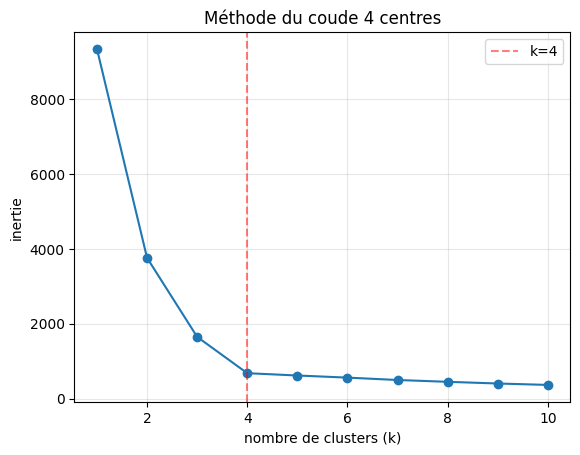

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, y = make_blobs(n_samples=1000, centers=4, cluster_std=0.6, random_state=0)

inerties = []
k_range = range(1, 11)

for k in k_range:
    model = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    inerties.append(model.inertia_)

plt.plot(k_range, inerties, marker='o')
plt.axvline(4, color='red', linestyle='--', alpha=0.5, label='k=4')
plt.xlabel('nombre de clusters (k)')
plt.ylabel('inertie')
plt.legend()
plt.title('Méthode du coude 4 centres')
plt.grid(alpha=0.3)
plt.show()

In [60]:
print('inerties :', [round(i) for i in inerties])
print('chutes :', [round(d) for d in np.diff(inerties)])

inerties : [9340, 3761, 1650, 680, 619, 562, 498, 450, 405, 367]
chutes : [-5579, -2110, -970, -62, -57, -64, -49, -45, -38]


In [61]:
# Exercice 2

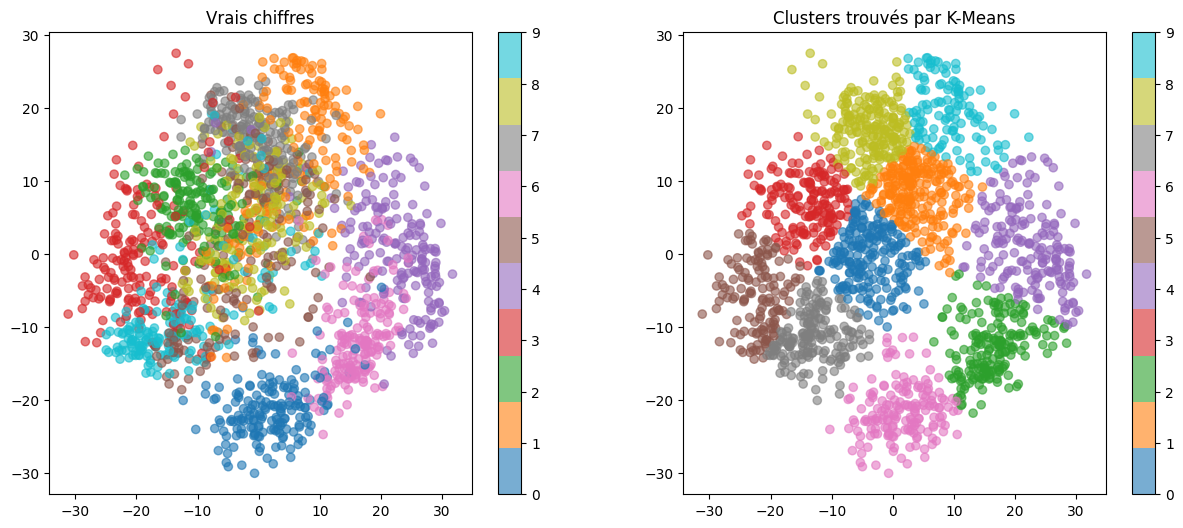

In [62]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

digits = load_digits()
X = digits.data
y = digits.target

# Réduire à 2D
X_reduced = PCA(n_components=2).fit_transform(X)

# K-Means avec 10 clusters
kmeans = KMeans(n_clusters=10, n_init=10, random_state=0)
clusters = kmeans.fit_predict(X_reduced)

# Comparaison visuelle : vrais chiffres à gauche, clusters à droite
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sc1 = ax1.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, cmap='tab10', alpha=0.6)
ax1.set_title('Vrais chiffres')
plt.colorbar(sc1, ax=ax1)

sc2 = ax2.scatter(X_reduced[:, 0], X_reduced[:, 1], c=clusters, cmap='tab10', alpha=0.6)
ax2.set_title('Clusters trouvés par K-Means')
plt.colorbar(sc2, ax=ax2)

plt.show()

In [63]:
from sklearn.metrics import adjusted_rand_score

score = adjusted_rand_score(y, clusters)
print('correspondance clusters / vrais chiffres :', round(score, 3))

correspondance clusters / vrais chiffres : 0.393


In [64]:
X_reduced_29 = PCA(n_components=0.95).fit_transform(X)
clusters_29 = KMeans(n_clusters=10, n_init=10, random_state=0).fit_predict(X_reduced_29)
print('score en 2D :', round(adjusted_rand_score(y, clusters), 3))
print('score en 29D :', round(adjusted_rand_score(y, clusters_29), 3))

score en 2D : 0.393
score en 29D : 0.667


In [65]:
# Exercice 3

In [66]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
import numpy as np

digits = load_digits()
X = digits.data  # 64 dimensions

model = PCA(n_components=64).fit(X)
variance_cumulee = np.cumsum(model.explained_variance_ratio_)

print(f'{"seuil":<8} {"composantes":<13} {"dimensions gagnées":<20}')
print('-' * 41)
for seuil in [0.90, 0.95, 0.99]:
    n = np.argmax(variance_cumulee > seuil) + 1
    print(f'{int(seuil*100)}%      {n:<13} {64 - n:<20}')

seuil    composantes   dimensions gagnées  
-----------------------------------------
90%      21            43                  
95%      29            35                  
99%      41            23                  


In [67]:
n90 = np.argmax(variance_cumulee > 0.90) + 1
n95 = np.argmax(variance_cumulee > 0.95) + 1
n99 = np.argmax(variance_cumulee > 0.99) + 1

print(f'de 90 à 95 % (+5 pts) : +{n95 - n90} composantes')
print(f'de 95 à 99 % (+4 pts) : +{n99 - n95} composantes')

de 90 à 95 % (+5 pts) : +8 composantes
de 95 à 99 % (+4 pts) : +12 composantes
